# Value Function Iteration — Auerbach-Kotlikoff OLG Model

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.io import loadmat

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})


In [3]:
import os

# define your output folder
output_dir = r"C:\Users\russale86005\Dropbox\TEACHING\Advanced Macro Fiscal Policies\New_Course_OLG_2026\Lectures\02_pensions_and_public_debt\code\Python\Output"
os.makedirs(output_dir, exist_ok=True)

## 1.  Utility and factor-price functions

In [6]:
def u_func(c, l, sigma, gam, psi0):
    """Instantaneous utility u(c, l)."""
    if sigma == 1:
        return np.log(c + psi0) + gam * np.log(1.0 - l)
    return (((c + psi0) * (1.0 - l) ** gam) ** (1.0 - sigma) - 1.0) / (1.0 - sigma)


def interest_rate(k, l, alpha0, delta):
    """r(K, L) from Cobb-Douglas production."""
    return alpha0 * k ** (alpha0 - 1.0) * l ** (1.0 - alpha0) - delta


def wage_rate(k, l, alpha0):
    """w(K, L) from Cobb-Douglas production."""
    return (1.0 - alpha0) * k ** alpha0 * l ** (-alpha0)


## 2.  Piecewise-linear interpolation

In [9]:
def interp_vf(x, agrid, vcol, assetmin, assetmax, neg):
    """
    Evaluate the interpolated value function at x.
      x < assetmin  →  neg        (infeasible)
      x >= assetmax →  vcol[-1]   (clamp at upper boundary)
      otherwise     →  np.interp  (linear)
    """
    if x < assetmin:
        return neg
    if x >= assetmax:
        return vcol[-1]
    return float(np.interp(x, agrid, vcol))


## 3.  Golden section search
Maximises a unimodal 1-D function without derivatives.

In [12]:
def golden_max(f, ay, by, cy, tol):
    """
    Maximise f on [ay, cy].  by is an interior bracket point (ay <= by <= cy).
    Maximises a unimodal 1-D function without derivatives.
    """
    R1 = 0.61803399
    R2 = 1.0 - R1
    x0, x3 = ay, cy
    if abs(cy - by) <= abs(by - ay):
        x1 = by
        x2 = by + R2 * (cy - by)
    else:
        x2 = by
        x1 = by - R2 * (by - ay)
    f1 = -f(x1)
    f2 = -f(x2)
    while abs(x3 - x0) >= tol * max(1.0, abs(x1) + abs(x2)):
        if f2 < f1:
            x0 = x1;  x1 = x2
            x2 = R1 * x1 + R2 * x3
            f1 = f2;  f2 = -f(x2)
        else:
            x3 = x2;  x2 = x1
            x1 = R1 * x2 + R2 * x0
            f2 = f1;  f1 = -f(x1)
    return x1 if f1 <= f2 else x2


## 4.  Bellman RHS functions

In [15]:
def make_bellman_retired(k0, r, pen, beta0, agrid, vnext_col,
                        assetmin, assetmax, neg, sigma, gam, psi0):
    """Bellman RHS for a retired agent with current wealth k0. Argument: x = a'."""
    def value1(x):
        c = (1.0 + r) * k0 + pen - x
        if c <= 0.0:
            return neg
        return u_func(c, 0.0, sigma, gam, psi0) + beta0 * interp_vf(
            x, agrid, vnext_col, assetmin, assetmax, neg)
    return value1


def make_bellman_worker(k0, r, w, tau, pen, beta0, agrid, vnext_col,
                        assetmin, assetmax, neg, sigma, gam, psi0):
    """
    Bellman RHS for a working agent with current wealth k0.
    Labour supply is substituted out via the closed-form intratemporal FOC.
    Argument: x = a'.
    """
    def value2(x):
        n = (1.0 / (1.0 + gam)) * (
            1.0 - gam / ((1.0 - tau) * w) * (psi0 + (1.0 + r) * k0 - x))
        n = max(0.0, min(1.0, n))
        c = (1.0 - tau) * w * n + (1.0 + r) * k0 - x
        if c <= 0.0:
            return neg
        return u_func(c, n, sigma, gam, psi0) + beta0 * interp_vf(
            x, agrid, vnext_col, assetmin, assetmax, neg)
    return value2


## 5.  Bracket-then-golden

In [18]:
def bracket_and_maximise(f, agrid, na, aeps, tol_golden, neg, m0_init):
    """
    Exploit monotonicity of the policy function to bracket the optimum,
    then refine with golden section search.

    m0_init  -- 0-indexed position of the previous grid node's optimum
                (used to warm-start the bracket search).
    Returns (x_opt, v_opt, m0_new).
    """
    assetmin = agrid[0]
    assetmax = agrid[-1]
    ax, bx, cx = 0.0, -1.0, -2.0
    v0     = neg
    m0_new = 0

    # Bug fix: initialise to -1 so first m+=1 checks agrid[0] when m0_init=0
    m = max(-1, m0_init - 3)

    while (ax > bx) or (bx > cx):
        m += 1
        if m >= na:
            # Bug fix §5.1: was  agid(m-1), a(m), a(m)  in the MATLAB original
            ax = agrid[na - 2]
            bx = agrid[na - 1]
            cx = agrid[na - 1]
            m0_new = na - 1
            break
        v1 = f(agrid[m])
        if v1 > v0:
            ax = agrid[0] if m == 0 else agrid[m - 1]
            bx = agrid[m]
            v0 = v1
            m0_new = m
        else:
            cx = agrid[m]

    # Refine with golden section search
    if ax == bx:                              # corner: assetmin?
        if f(assetmin) > f(assetmin + aeps):
            x_opt = assetmin
        else:
            x_opt = golden_max(f, assetmin, assetmin + aeps, agrid[1], tol_golden)
    elif bx == cx:                            # corner: assetmax?
        if f(assetmax) > f(assetmax - aeps):
            x_opt = assetmax
        else:
            x_opt = golden_max(f, agrid[-2], assetmax - aeps, assetmax, tol_golden)
    else:                                     # interior solution
        x_opt = golden_max(f, ax, bx, cx, tol_golden)

    return x_opt, f(x_opt), m0_new


## 6.  VFI backward pass

In [21]:
def vfi_backward(r, w, pen, p):
    """
    Complete backward-induction VFI for one set of prices (r, w, pen).
    Returns all policy and value function arrays.
    """
    beta0, sigma, gam, psi0 = p['beta0'], p['sigma'], p['gam'], p['psi0']
    tau, t, tr, na           = p['tau'], p['t'], p['tr'], p['na']
    agrid, assetmin, assetmax= p['agrid'], p['assetmin'], p['assetmax']
    aeps, tol_golden, neg    = p['aeps'], p['tol_golden'], p['neg']

    vr    = np.zeros((na, tr))
    aropt = np.zeros((na, tr))
    cropt = np.zeros((na, tr))
    vw    = np.zeros((na, t))
    awopt = np.zeros((na, t))
    cwopt = np.zeros((na, t))
    nwopt = np.zeros((na, t))

    # --- Terminal condition: last retirement period -------------------------
    for i in range(na):
        c_last = agrid[i] * (1.0 + r) + pen
        vr[i, tr - 1]    = u_func(c_last, 0.0, sigma, gam, psi0)
        cropt[i, tr - 1] = c_last

    # --- Retired agents: s = tr-2, ..., 0 (MATLAB: tr-1, ..., 1) ----------
    for s in range(tr - 2, -1, -1):
        vnext = vr[:, s + 1]
        m0 = 0
        for ia in range(na):
            f = make_bellman_retired(agrid[ia], r, pen, beta0, agrid, vnext,
                                     assetmin, assetmax, neg, sigma, gam, psi0)
            x, v, m0     = bracket_and_maximise(f, agrid, na, aeps, tol_golden, neg, m0)
            aropt[ia, s] = x
            vr[ia, s]    = v
            cropt[ia, s] = (1.0 + r) * agrid[ia] + pen - x

    # --- Workers: s = t-1, ..., 0 (MATLAB: t, ..., 1) ---------------------
    for s in range(t - 1, -1, -1):
        vnext = vr[:, 0] if s == t - 1 else vw[:, s + 1]
        m0 = 0
        for ia in range(na):
            f = make_bellman_worker(agrid[ia], r, w, tau, pen, beta0, agrid, vnext,
                                    assetmin, assetmax, neg, sigma, gam, psi0)
            x, v, m0     = bracket_and_maximise(f, agrid, na, aeps, tol_golden, neg, m0)
            awopt[ia, s] = x
            vw[ia, s]    = v
            n = (1.0 / (1.0 + gam)) * (
                1.0 - gam / ((1.0 - tau) * w) * (psi0 + (1.0 + r) * agrid[ia] - x))
            nwopt[ia, s] = max(0.0, min(1.0, n))
            cwopt[ia, s] = (1.0 - tau) * w * nwopt[ia, s] + (1.0 + r) * agrid[ia] - x

    return vr, vw, aropt, cropt, awopt, cwopt, nwopt


## 7.  Forward simulation

In [24]:
def forward_simulate(awopt, aropt, r, w, pen, p):
    """
    Simulate one household from birth (a^1 = 0) along the policy functions.
    Returns kgen (T,), ngen (t,), cgen (T,), vexact (scalar).
    """
    beta0, sigma, gam, psi0 = p['beta0'], p['sigma'], p['gam'], p['psi0']
    tau, t, tr, agrid        = p['tau'], p['t'], p['tr'], p['agrid']
    T = t + tr

    kgen   = np.zeros(T)
    ngen   = np.zeros(t)
    cgen   = np.zeros(T)
    vexact = 0.0

    for j in range(T - 1):
        if j < t:                                     # worker
            kgen[j + 1] = float(np.interp(kgen[j], agrid, awopt[:, j]))
            n = (1.0 / (1.0 + gam)) * (
                1.0 - gam / ((1.0 - tau) * w) * (
                    psi0 + (1.0 + r) * kgen[j] - kgen[j + 1]))
            ngen[j] = max(0.0, min(1.0, n))
            cgen[j] = (1.0 - tau) * w * ngen[j] + (1.0 + r) * kgen[j] - kgen[j + 1]
        else:                                         # retiree
            kgen[j + 1] = float(np.interp(kgen[j], agrid, aropt[:, j - t]))
            cgen[j]     = (1.0 + r) * kgen[j] + pen - kgen[j + 1]
        lj = ngen[j] if j < t else 0.0
        vexact += beta0 ** j * u_func(cgen[j], lj, sigma, gam, psi0)

    cgen[T - 1] = (1.0 + r) * kgen[T - 1] + pen
    vexact += beta0 ** (T - 1) * u_func(cgen[T - 1], 0.0, sigma, gam, psi0)
    return kgen, ngen, cgen, vexact


## 8.  Parameters

In [27]:
# ── Calibration ──────────────────────────────────────────────────────────────
p = dict(
    beta0      = 0.96,    # discount factor
    sigma      = 2.0,     # CRRA coefficient
    gam        = 2.0,     # disutility of labour
    alpha0     = 0.36,    # capital share
    delta      = 0.10,    # depreciation rate
    rep        = 0.30,    # pension replacement ratio
    psi0       = 0.001,   # consumption floor (utility parameter)
    phi        = 0.80,    # dampening parameter for GE update
    tol        = 1e-3,    # convergence tolerance on K and N
    tol_golden = 1e-8,    # golden section search tolerance
    neg        = -1e10,   # large negative value (infeasibility flag)
    t          = 40,      # working periods
    tr         = 20,      # retirement periods
    na         = 200,     # number of asset grid points
    assetmin   = 0.0,     # borrowing constraint
    assetmax   = 10.0,    # upper bound of asset grid
)

p['tau']   = p['rep'] / (2.0 + p['rep'])          # labour income tax
p['agrid'] = np.linspace(0.0, p['assetmax'], p['na'])
p['aeps']  = (p['agrid'][1] - p['agrid'][0]) / 10.0

print(f"tau  = {p['tau']:.4f}")
print(f"aeps = {p['aeps']:.6f}")
print(f"Grid: {p['na']} points on [{p['assetmin']}, {p['assetmax']}]")


tau  = 0.1304
aeps = 0.005025
Grid: 200 points on [0.0, 10.0]


## 9.  General equilibrium loop

In [30]:
# ── Initial guesses ───────────────────────────────────────────────────────────
nbar = 0.20
kbar = (p['alpha0'] / (0.045 + p['delta'])) ** (1.0 / (1.0 - p['alpha0'])) * nbar
kold, nold = 100.0, 2.0

print(f"Initial guess:  K = {kbar:.4f},  N = {nbar:.4f}")
print()
print(f"{'q':>4}  {'K':>10}  {'N':>10}  {'r':>8}  {'w':>8}  {'krit':>10}")
print("-" * 58)

q    = 0
krit = 1.0 + p['tol']
t0   = time.time()

# ── Bug fix §5.2: exit as soon as krit < tol (run at least once) ─────────────
while krit > p['tol'] or q < 1:
    q    += 1
    krit  = abs((kbar - kold) / max(abs(kbar), 1e-12))

    r   = interest_rate(kbar, nbar, p['alpha0'], p['delta'])
    w   = wage_rate(kbar, nbar, p['alpha0'])
    pen = p['rep'] * (1.0 - p['tau']) * w * nbar * 3.0 / 2.0
    kold, nold = kbar, nbar

    print(f"{q:>4}  {kbar:>10.6f}  {nbar:>10.6f}  {r:>8.5f}  {w:>8.5f}  {krit:>10.2e}")

    vr, vw, aropt, cropt, awopt, cwopt, nwopt = vfi_backward(r, w, pen, p)
    kgen, ngen, cgen, vexact = forward_simulate(awopt, aropt, r, w, pen, p)

    knew = kgen.mean()
    nnew = ngen.mean() * 2.0 / 3.0
    kbar = p['phi'] * kold + (1.0 - p['phi']) * knew
    nbar = p['phi'] * nold + (1.0 - p['phi']) * nnew

elapsed = time.time() - t0
print("-" * 58)
print(f"Converged in {q} iterations  ({elapsed/60:.1f} min)")
print(f"K = {kbar:.6f}   N = {nbar:.6f}   r = {r:.6f}   w = {w:.6f}   pen = {pen:.6f}")


Initial guess:  K = 0.8282,  N = 0.2000

   q           K           N         r         w        krit
----------------------------------------------------------
   1    0.828162    0.200000   0.04500   1.06741    1.20e+02
   2    0.818681    0.205403   0.04859   1.05284    1.16e-02
   3    0.829715    0.209189   0.04905   1.05099    1.33e-02
   4    0.839566    0.212144   0.04926   1.05015    1.17e-02
   5    0.847454    0.214477   0.04941   1.04955    9.31e-03
   6    0.853681    0.216319   0.04953   1.04909    7.29e-03
   7    0.858564    0.217775   0.04963   1.04871    5.69e-03
   8    0.862303    0.218919   0.04971   1.04837    4.34e-03
   9    0.865211    0.219816   0.04978   1.04810    3.36e-03
  10    0.867482    0.220517   0.04984   1.04789    2.62e-03
  11    0.869271    0.221066   0.04988   1.04773    2.06e-03
  12    0.870683    0.221496   0.04991   1.04761    1.62e-03
  13    0.871796    0.221834   0.04993   1.04751    1.28e-03
  14    0.872673    0.222099   0.04995   1.047

## 10.  Life-cycle profiles

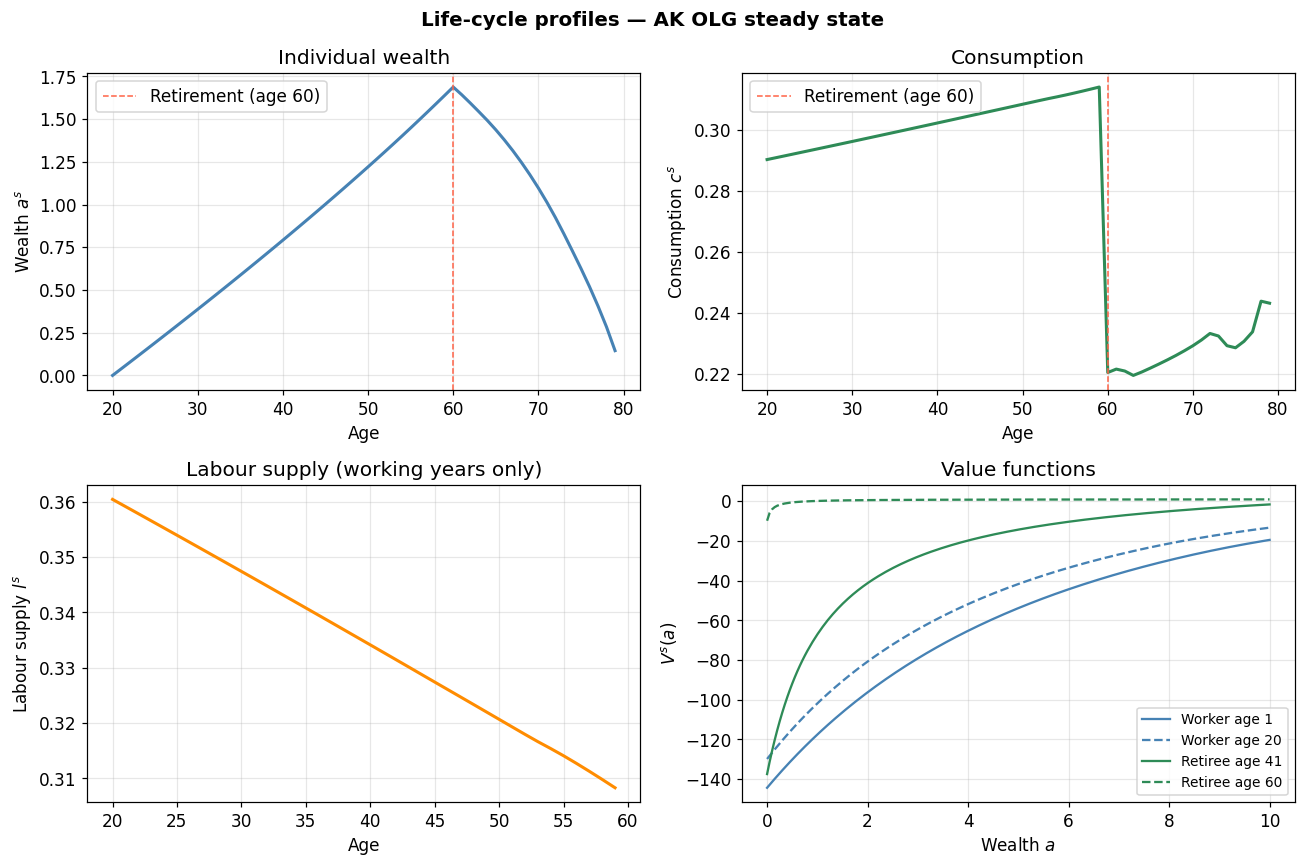

In [39]:
ages    = np.arange(20, 80)          # real-life ages 20-79
ages_w  = np.arange(20, 60)          # workers only

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Life-cycle profiles — AK OLG steady state", fontsize=13, fontweight='bold')

ax = axes[0, 0]
ax.plot(ages, kgen, color='steelblue', linewidth=2)
ax.axvline(60, color='tomato', linestyle='--', linewidth=1, label='Retirement (age 60)')
ax.set_xlabel('Age'); ax.set_ylabel('Wealth $a^s$')
ax.set_title('Individual wealth'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ages, cgen, color='seagreen', linewidth=2)
ax.axvline(60, color='tomato', linestyle='--', linewidth=1, label='Retirement (age 60)')
ax.set_xlabel('Age'); ax.set_ylabel('Consumption $c^s$')
ax.set_title('Consumption'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(ages_w, ngen, color='darkorange', linewidth=2)
ax.set_xlabel('Age'); ax.set_ylabel('Labour supply $l^s$')
ax.set_title('Labour supply (working years only)'); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(p['agrid'], vw[:, 0],  label='Worker age 1',   color='steelblue')
ax.plot(p['agrid'], vw[:, 19], label='Worker age 20',  color='steelblue', linestyle='--')
ax.plot(p['agrid'], vr[:, 0],  label='Retiree age 41', color='seagreen')
ax.plot(p['agrid'], vr[:, 19], label='Retiree age 60', color='seagreen', linestyle='--')
ax.set_xlabel('Wealth $a$'); ax.set_ylabel('$V^s(a)$')
ax.set_title('Value functions'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'olg_ak60_vfi_policy.png'), dpi=150, bbox_inches='tight')
plt.show()


## 11.  Policy functions at selected ages

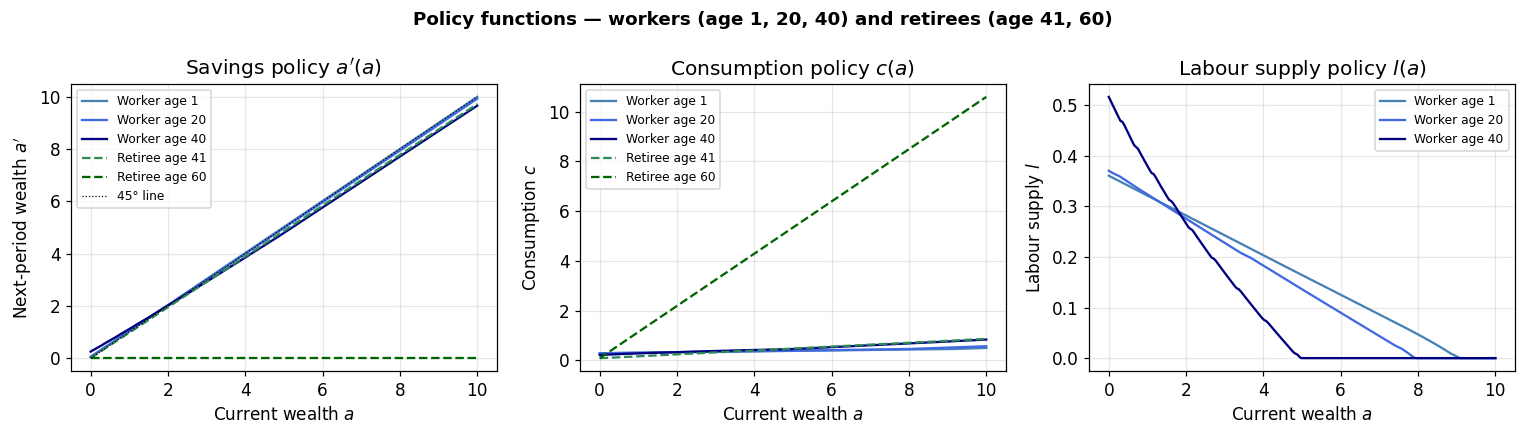

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Policy functions — workers (age 1, 20, 40) and retirees (age 41, 60)",
             fontsize=12, fontweight='bold')

ages_show_w = [0, 19, 39]          # Python indices → ages 1, 20, 40
ages_show_r = [0, 19]              # Python indices → ages 41, 60
labels_w = ['Worker age 1', 'Worker age 20', 'Worker age 40']
labels_r = ['Retiree age 41', 'Retiree age 60']
colors_w = ['steelblue', 'royalblue', 'navy']
colors_r = ['seagreen', 'darkgreen']

ax = axes[0]
for idx, lbl, col in zip(ages_show_w, labels_w, colors_w):
    ax.plot(p['agrid'], awopt[:, idx], label=lbl, color=col)
for idx, lbl, col in zip(ages_show_r, labels_r, colors_r):
    ax.plot(p['agrid'], aropt[:, idx], label=lbl, color=col, linestyle='--')
ax.plot(p['agrid'], p['agrid'], 'k:', linewidth=0.8, label="45° line")
ax.set_xlabel("Current wealth $a$"); ax.set_ylabel("Next-period wealth $a'$")
ax.set_title("Savings policy $a'(a)$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for idx, lbl, col in zip(ages_show_w, labels_w, colors_w):
    ax.plot(p['agrid'], cwopt[:, idx], label=lbl, color=col)
for idx, lbl, col in zip(ages_show_r, labels_r, colors_r):
    ax.plot(p['agrid'], cropt[:, idx], label=lbl, color=col, linestyle='--')
ax.set_xlabel("Current wealth $a$"); ax.set_ylabel("Consumption $c$")
ax.set_title("Consumption policy $c(a)$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
for idx, lbl, col in zip(ages_show_w, labels_w, colors_w):
    ax.plot(p['agrid'], nwopt[:, idx], label=lbl, color=col)
ax.set_xlabel("Current wealth $a$"); ax.set_ylabel("Labour supply $l$")
ax.set_title("Labour supply policy $l(a)$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'olg_ak60_vfi_policy2.png'), dpi=150, bbox_inches='tight')
plt.show()
